# Day 10: Entanglement and your first Qiskit circuit

**Thu, Oct 15 · Intro · about 30 minutes**

Entanglement is a two-qubit state that can't be split into two separate one-qubit states. Today you build the most famous one by hand and then with Qiskit, the toolkit the course labs use.

**By the end of this notebook you can:**
- Tell a product state from an entangled one
- Build the Bell state with H and CNOT, first in NumPy, then in Qiskit
- Run a simulated measurement and read the counts

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

### Setup
If you're running this on your own machine, install Qiskit first (one time):
```
pip install qiskit qiskit-aer matplotlib
```

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

## 1. The CNOT gate
CNOT flips the second qubit **only if** the first is |1⟩:  |00⟩→|00⟩, |01⟩→|01⟩, |10⟩→|11⟩, |11⟩→|10⟩.

In [2]:
CNOT = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1],
                 [0, 0, 1, 0]])
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2); I = np.eye(2)

## 2. Build the Bell state by hand
Start in |00⟩ → apply H to the first qubit → apply CNOT.
In this NumPy section the **first qubit (q0) is written on the left**, so `np.kron(q0, q1)`. Qiskit does the reverse (see section 4); for the Bell state the two conventions give the same picture.

start |00>      {'00': np.float64(1.0), '01': np.float64(0.0), '10': np.float64(0.0), '11': np.float64(0.0)}
after H on q0   {'00': np.float64(0.7071), '01': np.float64(0.0), '10': np.float64(0.7071), '11': np.float64(0.0)}
after CNOT      {'00': np.float64(0.7071), '01': np.float64(0.0), '10': np.float64(0.0), '11': np.float64(0.7071)}


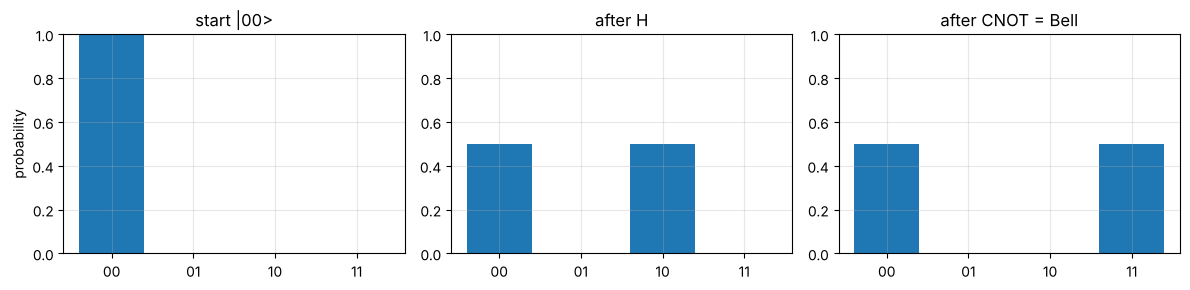

In [3]:
s0 = np.kron(ket0, ket0)
s1 = np.kron(H, I) @ s0
s2 = CNOT @ s1
labels = ["00", "01", "10", "11"]
for name, s in [("start |00>", s0), ("after H on q0", s1), ("after CNOT", s2)]:
    print(f"{name:15s}", dict(zip(labels, np.round(s.real, 4))))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, s) in zip(axes, [("start |00>", s0), ("after H", s1), ("after CNOT = Bell", s2)]):
    ax.bar(labels, np.abs(s) ** 2, color="C0"); ax.set_ylim(0, 1); ax.set_title(name)
axes[0].set_ylabel("probability"); plt.tight_layout(); plt.show()

## 3. Why it's entangled
A product state (a|0⟩ + b|1⟩) ⊗ (c|0⟩ + d|1⟩) has amplitudes (ac, ad, bc, bd). Arrange them in a 2×2 grid:
the grid of a product state always has **determinant ac·bd − ad·bc = 0**.
The Bell state's grid is [[1/√2, 0], [0, 1/√2]], with determinant 1/2 ≠ 0. So it can't be factored, and it's entangled.

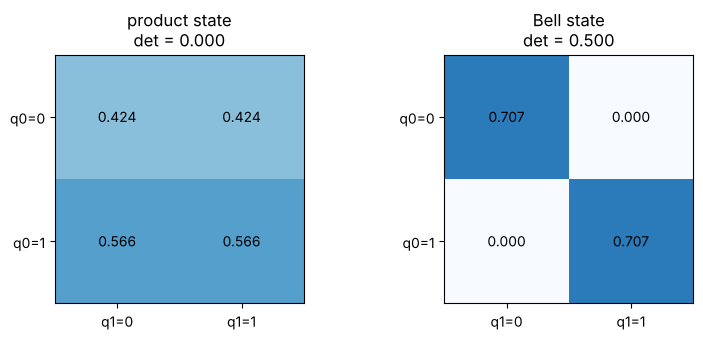

In [4]:
product = np.kron(np.array([0.6, 0.8]), plus.real)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, s) in zip(axes, [("product state", product), ("Bell state", s2.real)]):
    grid = s.reshape(2, 2)
    ax.imshow(np.abs(grid), cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center")
    ax.set_xticks([0, 1], ["q1=0", "q1=1"]); ax.set_yticks([0, 1], ["q0=0", "q0=1"])
    ax.set_title(f"{name}\ndet = {np.linalg.det(grid):.3f}"); ax.grid(False)
plt.tight_layout(); plt.show()

## 4. The same thing in Qiskit
Qiskit builds the circuit for you and simulates measurements. One detail: **Qiskit prints bitstrings with qubit 0 on the right**, so the outcome where q1 = 0 and q0 = 1 is shown as `'01'`. For the Bell state it doesn't matter, since only `00` and `11` appear.

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
print(qc.draw("text"))

state = Statevector.from_instruction(qc)
print("statevector:", np.round(state.data, 4))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               
statevector: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
counts: {'00': 510, '11': 490}


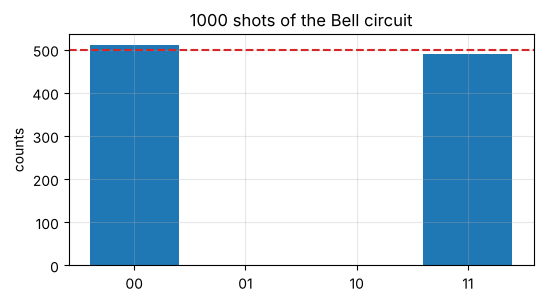

In [6]:
qc.measure([0, 1], [0, 1])
print(qc.draw("text"))
sim = AerSimulator()
counts = sim.run(transpile(qc, sim), shots=1000, seed_simulator=42).result().get_counts()
print("counts:", counts)

keys = ["00", "01", "10", "11"]
plt.figure(figsize=(6, 3)); plt.bar(keys, [counts.get(k, 0) for k in keys]); plt.axhline(500, color="C3", ls="--")
plt.title("1000 shots of the Bell circuit"); plt.ylabel("counts"); plt.show()

## Exercises
**E1.** Run the circuit with 1000 shots. Confirm `00` and `11` each appear about 500 times, and `01`/`10` never appear. Explain the zeros in one line.

**E2.** Show (|00⟩ + |11⟩)/√2 can't be written as (a|0⟩ + b|1⟩) ⊗ (c|0⟩ + d|1⟩).

**E3 (stretch).** Add `qc.x(1)` before the H in a fresh circuit. Which two outcomes appear now?

In [7]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** The state has zero amplitude on |01⟩ and |10⟩, so their probabilities are 0. The two qubits always agree.

**E2.** You'd need ac = 1/√2, bd = 1/√2, ad = 0 and bc = 0. ad = 0 means a = 0 or d = 0, but either one makes ac or bd zero. Contradiction, so no such factoring exists.

**E3.** X on qubit 1 makes the start |q1 q0⟩ = |10⟩. After H and CNOT you get (|01⟩ + |10⟩)/√2 in Qiskit's labels, so **`01` and `10`**, each about 500 times.

</details>

In [8]:
assert set(counts) <= {"00", "11"} and abs(counts["00"] - 500) < 80
qc2 = QuantumCircuit(2, 2); qc2.x(1); qc2.h(0); qc2.cx(0, 1); qc2.measure([0, 1], [0, 1])
c2 = sim.run(transpile(qc2, sim), shots=1000, seed_simulator=1).result().get_counts()
assert set(c2) <= {"01", "10"}
print("E3 counts:", c2)
print("All Day 10 checks passed.")

E3 counts: {'01': 509, '10': 491}
All Day 10 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 11 (intro): The Bloch sphere

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*